<a href="https://colab.research.google.com/github/alperyldzzz/Lab/blob/main/Lab7/Exercise3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Lab 7 - Exercise 3
------------------
Integral: from -1 to 3 of exp(-x^2) dx
Reference value: 1.6330314810719482

Results Table
Intervals | Left       | Right      | Midpoint   | Trapezoidal
--------------------------------------------------------------
        4 | 1.754075   | 1.386318   | 1.664931   | 1.570197
        8 | 1.709503   | 1.525625   | 1.640812   | 1.617564
       16 | 1.675157   | 1.583218   | 1.634956   | 1.629188
       32 | 1.655057   | 1.609087   | 1.633511   | 1.632072
       64 | 1.644284   | 1.621299   | 1.633151   | 1.632792

Error Table
Intervals | Left error | Right error | Midpoint error | Trapezoidal error
--------------------------------------------------------------------------
        4 | 0.121043   | 0.246713    | 0.031900       | 0.062835
        8 | 0.076471   | 0.107407    | 0.007780       | 0.015468
       16 | 0.042126   | 0.049813    | 0.001925       | 0.003844
       32 | 0.022025   | 0.023944    | 0.000480       | 0.000959
       64 | 0.011253   |

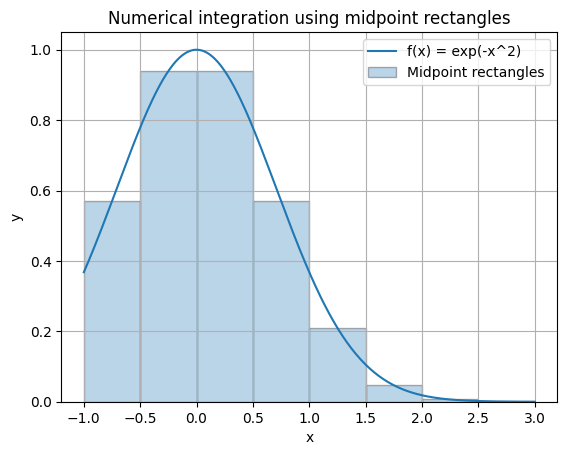

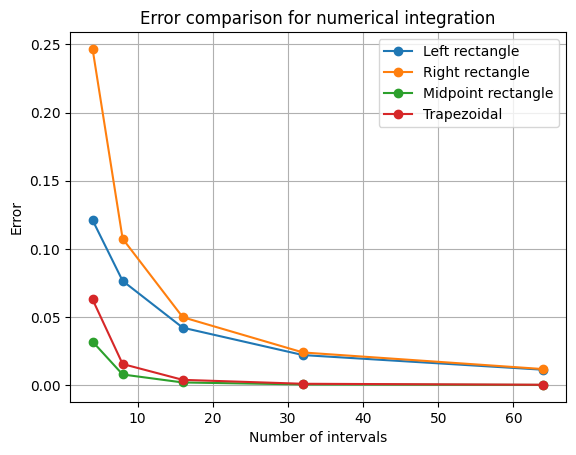

In [3]:
import numpy as np
import scipy.integrate as integrate
import matplotlib.pyplot as plt


def f(x):
    return np.exp(-x**2)


def left_rectangle(f, a, b, n):
    h = (b - a) / n
    x = np.linspace(a, b - h, n)
    return h * np.sum(f(x))


def right_rectangle(f, a, b, n):
    h = (b - a) / n
    x = np.linspace(a + h, b, n)
    return h * np.sum(f(x))


def midpoint_rectangle(f, a, b, n):
    h = (b - a) / n
    x = np.linspace(a + h / 2, b - h / 2, n)
    return h * np.sum(f(x))


def trapezoidal_method(f, a, b, n):
    h = (b - a) / n
    x = np.linspace(a, b, n + 1)
    y = f(x)
    return h * ((y[0] + y[-1]) / 2 + np.sum(y[1:-1]))


a = -1
b = 3

exact_value, _ = integrate.quad(f, a, b)

intervals = [4, 8, 16, 32, 64]

left_results = []
right_results = []
mid_results = []
trap_results = []

left_errors = []
right_errors = []
mid_errors = []
trap_errors = []

print("Lab 7 - Exercise 3")
print("------------------")
print("Integral: from -1 to 3 of exp(-x^2) dx")
print("Reference value:", exact_value)
print()

print("Results Table")
print("Intervals | Left       | Right      | Midpoint   | Trapezoidal")
print("--------------------------------------------------------------")

for n in intervals:
    left = left_rectangle(f, a, b, n)
    right = right_rectangle(f, a, b, n)
    mid = midpoint_rectangle(f, a, b, n)
    trap = trapezoidal_method(f, a, b, n)

    left_results.append(left)
    right_results.append(right)
    mid_results.append(mid)
    trap_results.append(trap)

    left_errors.append(abs(exact_value - left))
    right_errors.append(abs(exact_value - right))
    mid_errors.append(abs(exact_value - mid))
    trap_errors.append(abs(exact_value - trap))

    print(f"{n:9d} | {left:.6f}   | {right:.6f}   | {mid:.6f}   | {trap:.6f}")

print()
print("Error Table")
print("Intervals | Left error | Right error | Midpoint error | Trapezoidal error")
print("--------------------------------------------------------------------------")

for i, n in enumerate(intervals):
    print(
        f"{n:9d} | "
        f"{left_errors[i]:.6f}   | "
        f"{right_errors[i]:.6f}    | "
        f"{mid_errors[i]:.6f}       | "
        f"{trap_errors[i]:.6f}"
    )

x_curve = np.linspace(a, b, 400)
y_curve = f(x_curve)

n_plot = 8
h = (b - a) / n_plot
mid_points = np.linspace(a + h / 2, b - h / 2, n_plot)

plt.figure()
plt.plot(x_curve, y_curve, label="f(x) = exp(-x^2)")
plt.bar(mid_points, f(mid_points), width=h, alpha=0.3, edgecolor="black", label="Midpoint rectangles")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Numerical integration using midpoint rectangles")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(intervals, left_errors, marker="o", label="Left rectangle")
plt.plot(intervals, right_errors, marker="o", label="Right rectangle")
plt.plot(intervals, mid_errors, marker="o", label="Midpoint rectangle")
plt.plot(intervals, trap_errors, marker="o", label="Trapezoidal")
plt.xlabel("Number of intervals")
plt.ylabel("Error")
plt.title("Error comparison for numerical integration")
plt.legend()
plt.grid(True)
plt.show()